In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [ ]:
t1_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t1.slp'
t1_labels = sleap.load_file(t1_labels_path)
print(t1_labels)
t1_all_tracked_points = get_all_tracked_points(t1_labels, reorder=True)
t1_all_tracked_points.shape

In [4]:
predicted_10min_labels

Labels(labeled_frames=15790, videos=1, skeletons=1, tracks=0)

In [3]:
predicted_10min_labels.provenance

{}

In [2]:
c3_simplemax_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/simplemax-tracking/c3_simplemax_tracking.slp'
c3_simplemax_labels = sleap.load_file(c3_simplemax_labels_path)
print(c3_simplemax_labels)
c3_simplemax_tracked_points = get_all_tracked_points(c3_simplemax_labels, reorder=True)
c3_simplemax_tracked_points.shape

Labels(labeled_frames=828, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (827, 17, 2)
Missing point count: 105
reorder_idx.shape: (17,)


(827, 17, 2)

1. Find swapped IDs: when expanded (radius max), a point should be connected to its 2 closest neighbors; if not, considered as swapped
- ID the center 
- compute the radius for each point 
- if all point radius at least 50% max, ID as expanded

2. Correct (swap)

3. Propagate in time in both directions

## Identify frames where the jellyfish is expanded

### get center position

In [6]:
# frame1 = t1_labels.video.get_frame(1)

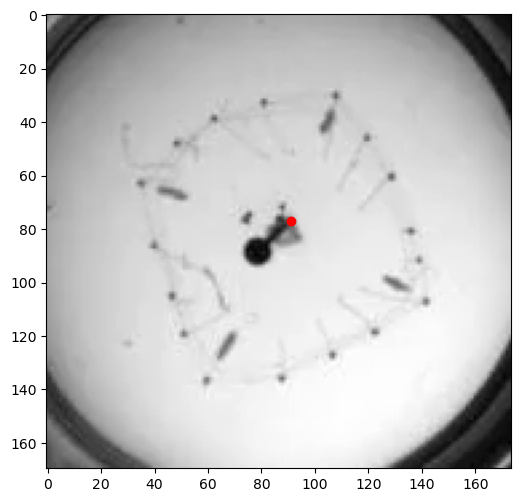

In [3]:
frame1 = c3_simplemax_labels.video.get_frame(1)
center_pos = np.array([91, 77])
plt.figure(figsize=(6, 6))
plt.imshow(frame1[:,:,0], cmap='gray')
plt.plot(center_pos[0], center_pos[1], 'ro')
plt.show()

### get radii for each point 

### c3

In [4]:
c3_all_radii = get_all_radii(c3_simplemax_tracked_points)

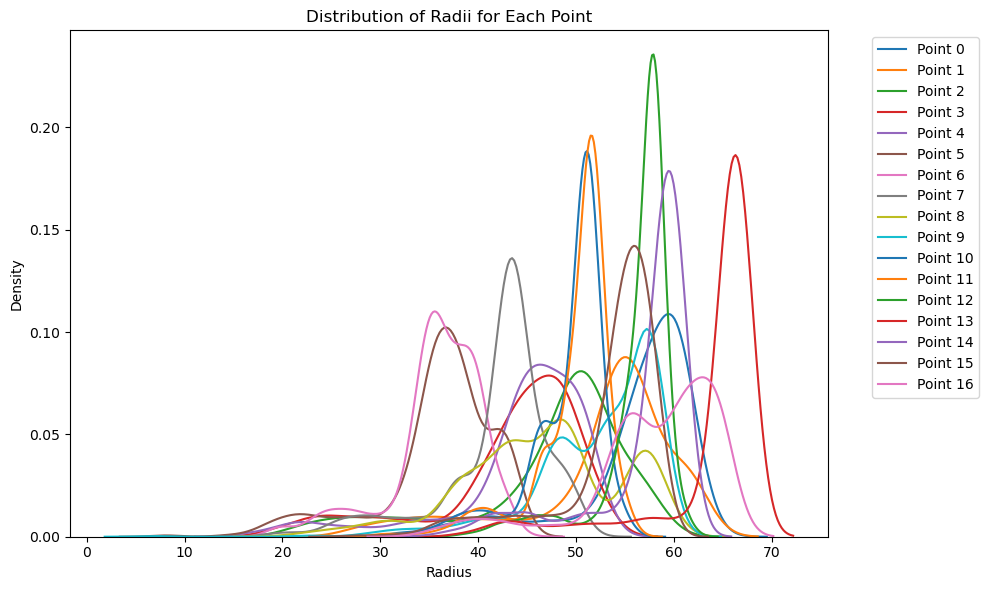

In [5]:
plot_radii_distribution(c3_all_radii)

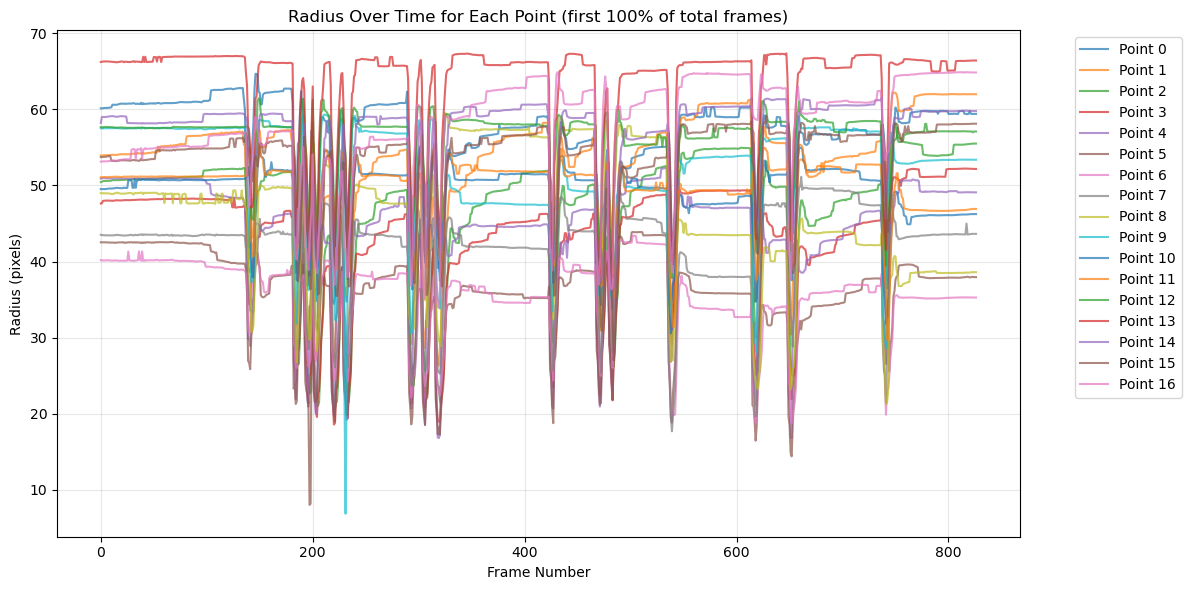

In [6]:
plot_radii_over_time(c3_all_radii, first_x_proportion=1)

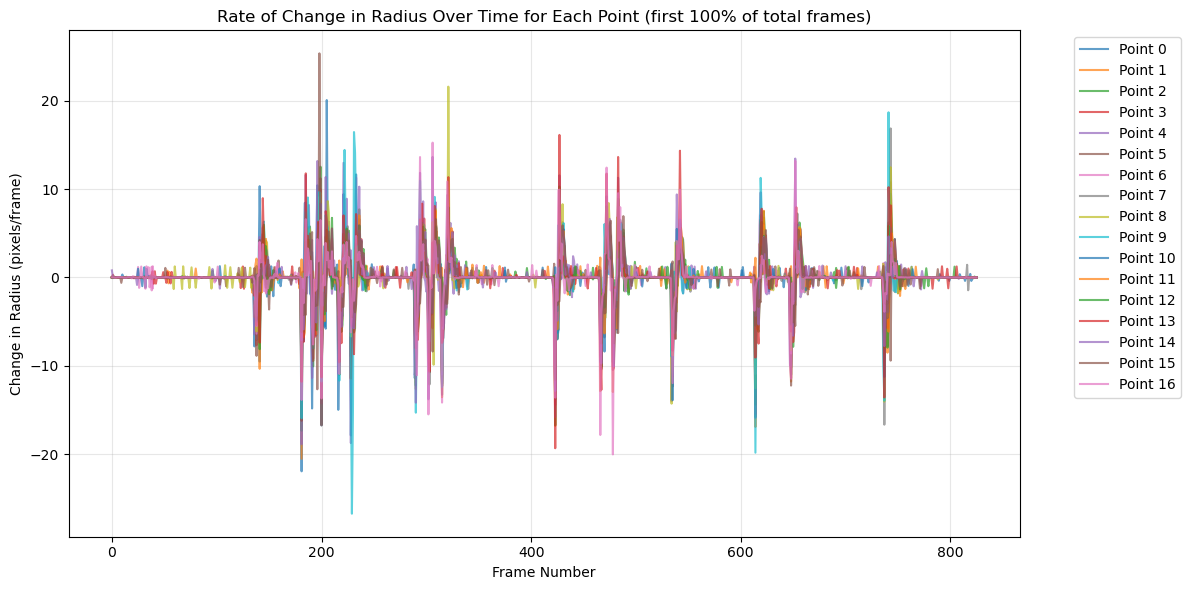

In [7]:
plot_radii_derivative(c3_all_radii)

mean_radii: [39.41235036 36.77156537 32.96337506 30.19876124 31.00064408 25.18907291
 25.03698122 29.29524444 32.52066016 36.6279706  34.33457673 34.83260854
 39.37058072 44.63699213 39.87832386 37.41372879 40.53542023]
Stable ranges (frame numbers) with minimum length of 20 frames and all radii above 70.0% mean:
    - Frames 0 to 135 (length: 135)
    - Frames 155 to 180 (length: 25)
    - Frames 241 to 288 (length: 47)
    - Frames 330 to 421 (length: 91)
    - Frames 441 to 465 (length: 24)
    - Frames 491 to 533 (length: 42)
    - Frames 548 to 612 (length: 64)
    - Frames 626 to 646 (length: 20)
    - Frames 660 to 735 (length: 75)
    - Frames 753 to 825 (length: 72)


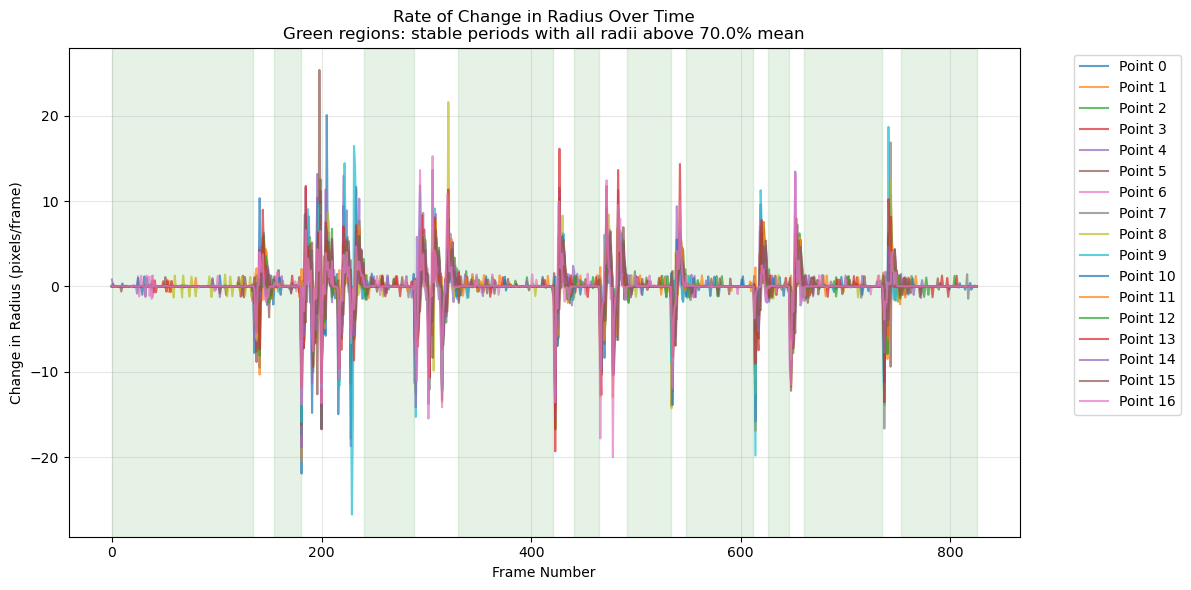

In [8]:
c3_filtered_ranges = get_expanded_periods(c3_all_radii, min_range_length=20, mean_scale=0.7, derivative_thres=2, plot=True)

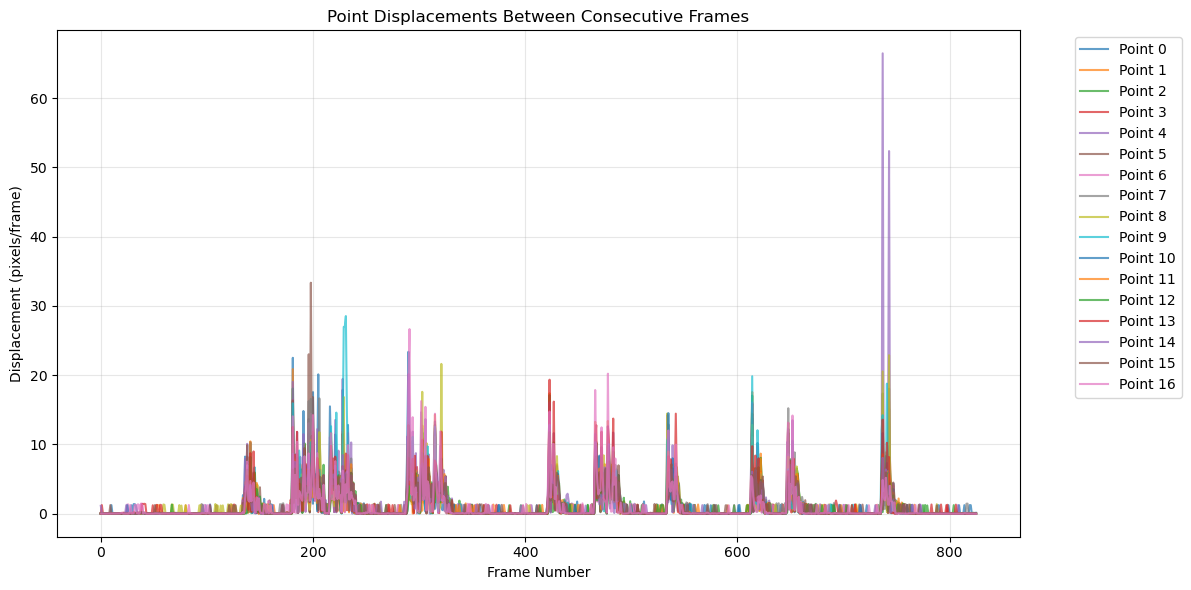

In [9]:
plt.figure(figsize=(12, 6))

# Calculate displacements between consecutive frames for each point
displacements = np.sqrt(np.sum((c3_simplemax_tracked_points[1:] - c3_simplemax_tracked_points[:-1])**2, axis=2))

# Plot displacement for each point
for i in range(displacements.shape[1]):
    plt.plot(range(displacements.shape[0]), displacements[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number')
plt.ylabel('Displacement (pixels/frame)')
plt.title('Point Displacements Between Consecutive Frames')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### t1

In [8]:
all_radii = np.zeros(t1_all_tracked_points.shape[:2])
for i in range(t1_all_tracked_points.shape[0]):
    for j in range(t1_all_tracked_points.shape[1]):
        all_radii[i, j] = np.linalg.norm(t1_all_tracked_points[i, j] - center_pos)

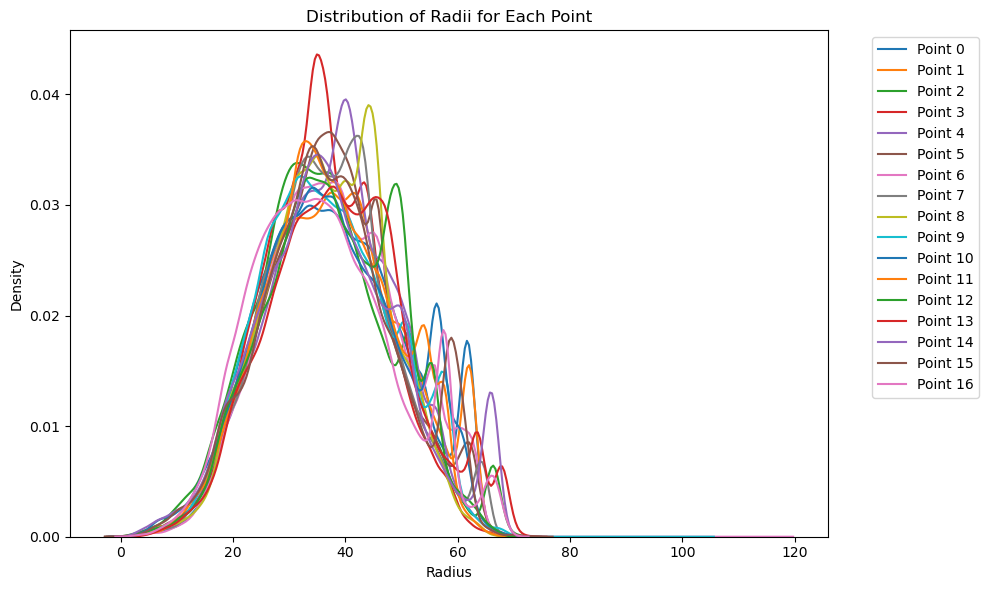

In [9]:
plt.figure(figsize=(10, 6))

# Plot KDE for each point
for i in range(all_radii.shape[1]):
    sns.kdeplot(data=all_radii[:, i], label=f'Point {i}')

plt.xlabel('Radius')
plt.ylabel('Density')
plt.title('Distribution of Radii for Each Point')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
print(all_radii.shape)
total_frame_cnt = all_radii.shape[0]

(90002, 17)


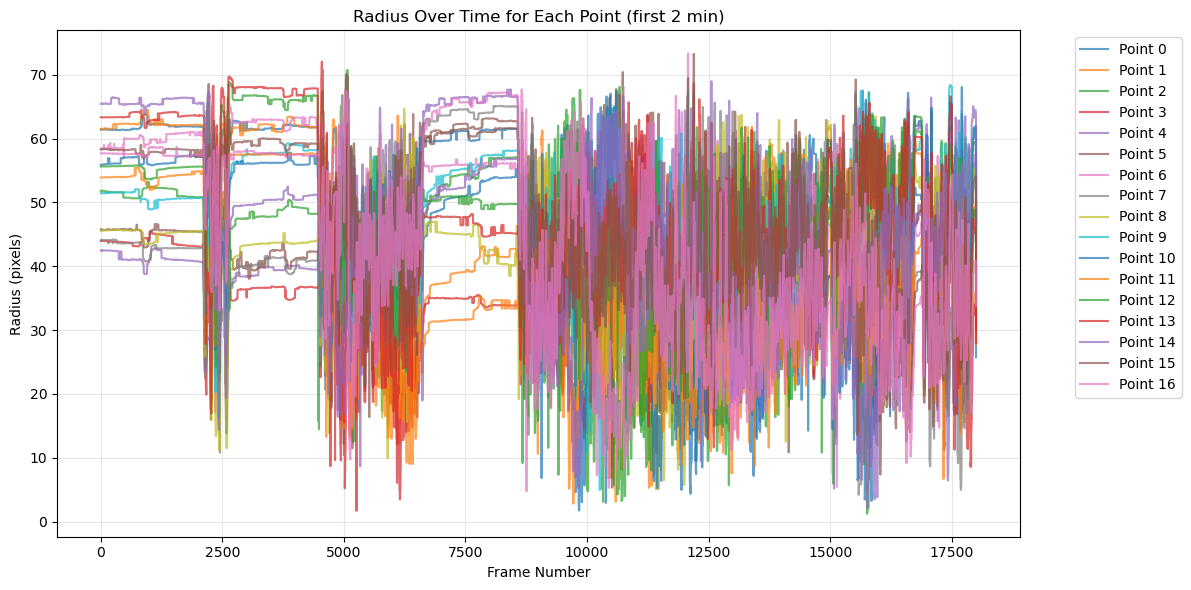

In [11]:
plt.figure(figsize=(12, 6))
x_minute = 2
first_x_min = all_radii[:int(total_frame_cnt / 10 * x_minute)]

# Plot time series for each point
for i in range(first_x_min.shape[1]):
    plt.plot(range(first_x_min.shape[0]), first_x_min[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number')
plt.ylabel('Radius (pixels)')
plt.title(f'Radius Over Time for Each Point (first {x_minute} min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### identify frames with less movement

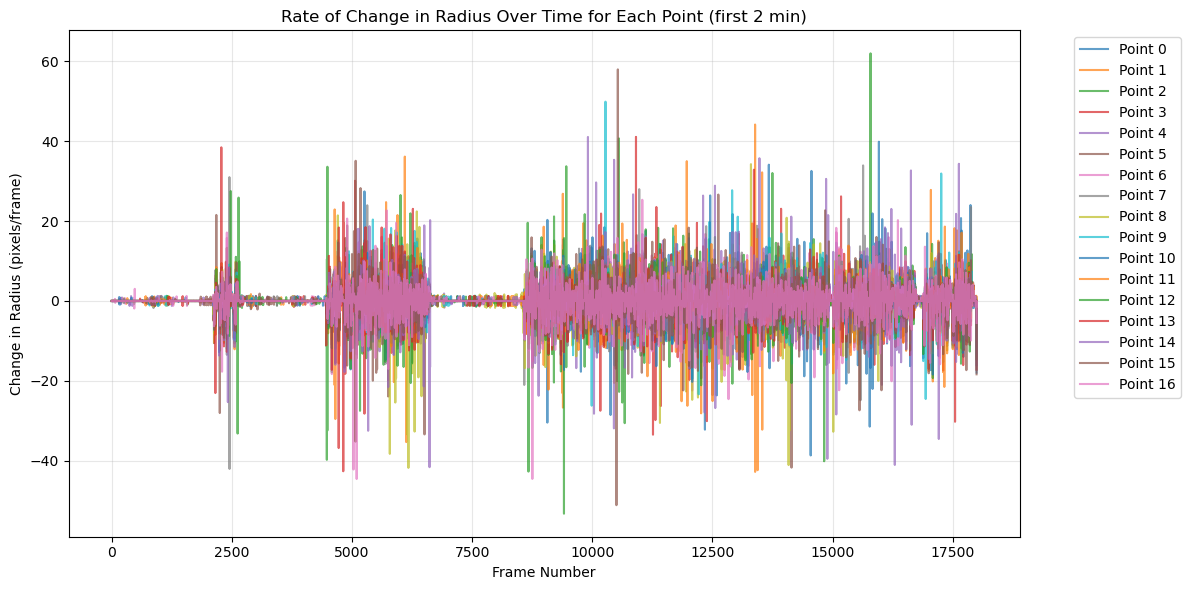

In [12]:
plt.figure(figsize=(12, 6))

# Calculate derivatives (differences between consecutive frames)
derivatives = np.diff(first_x_min, axis=0)

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number') 
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time for Each Point (first {x_minute} min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Stable ranges (frame numbers) with minimum length of 100 frames:
Frames 0 to 2126 (length: 2126)
Frames 2654 to 4462 (length: 1808)
Frames 6627 to 8570 (length: 1943)
Frames 16704 to 16888 (length: 184)


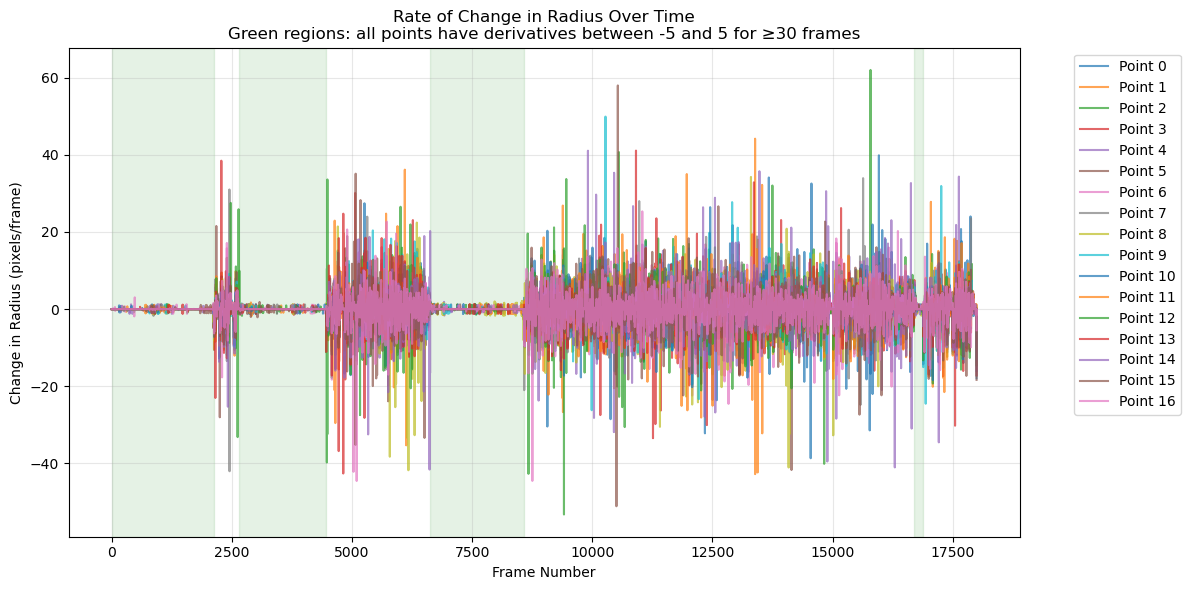

In [15]:
plt.figure(figsize=(12, 6))
min_range_length = 100

# Calculate derivatives
derivatives = np.diff(first_x_min, axis=0)

# Find ranges where all derivatives are between -5 and 5
all_stable = np.all((derivatives > -5) & (derivatives < 5), axis=1)
ranges = []
start_idx = None

# Find continuous ranges
for i in range(len(all_stable)):
    if all_stable[i] and start_idx is None:
        start_idx = i
    elif not all_stable[i] and start_idx is not None:
        if i - start_idx >= min_range_length:  # Only keep ranges at least 30 frames long
            ranges.append((start_idx, i))
        start_idx = None
        
if start_idx is not None and len(all_stable) - start_idx >= min_range_length:  # Handle case where last range extends to end
    ranges.append((start_idx, len(all_stable)))

# Print the ranges
print(f"Stable ranges (frame numbers) with minimum length of {min_range_length} frames:")
for start, end in ranges:
    print(f"Frames {start} to {end} (length: {end-start})")

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

# Add vertical bars for stable ranges
for start, end in ranges:
    plt.axvspan(start, end, color='green', alpha=0.1)

plt.xlabel('Frame Number')
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time\nGreen regions: all points have derivatives between -5 and 5 for ≥30 frames')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### filter for frames where all radius are above mean

mean_radii: [35.88887451 34.70696451 34.19926079 28.57396974 32.37398359 35.14246077
 37.28549895 33.62623162 32.6992762  37.32289639 35.42871798 30.23040408
 36.0028537  38.65460458 37.19667053 37.59074905 34.9025168 ]
Stable ranges (frame numbers) with minimum length of 100 frames and all radii above 80.0% mean:
    - Frames 0 to 2117 (length: 2117)
    - Frames 2654 to 4461 (length: 1807)
    - Frames 6745 to 8569 (length: 1824)


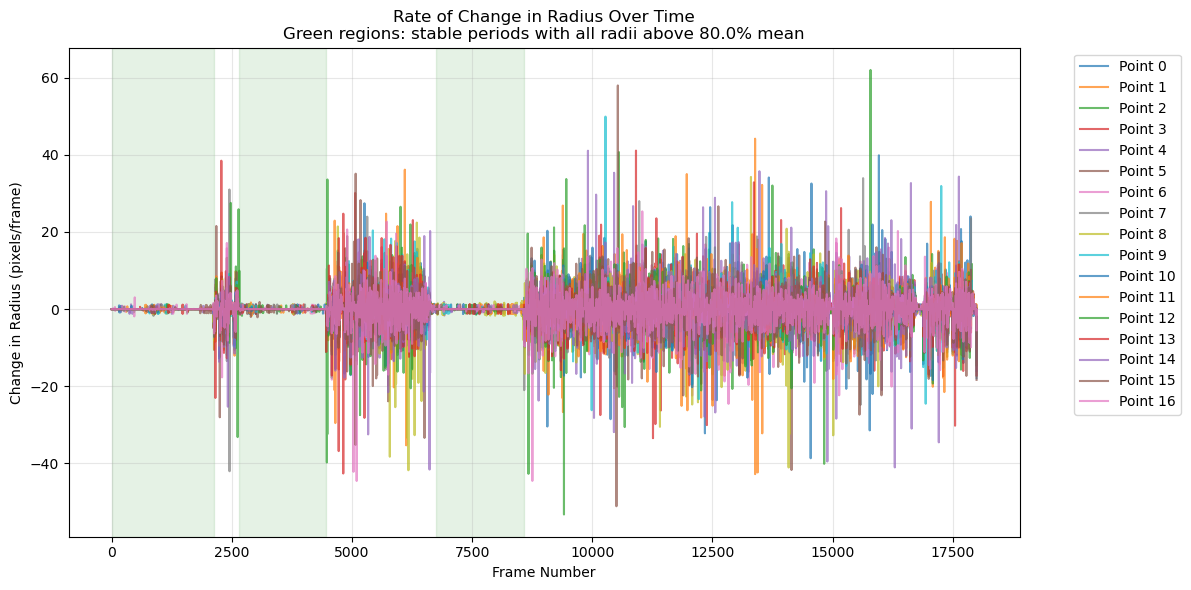

In [22]:
plt.figure(figsize=(12, 6))
min_range_length = 100

# Calculate derivatives
derivatives = np.diff(first_x_min, axis=0)

# Find ranges where all derivatives are between -5 and 5
all_stable = np.all((derivatives > -5) & (derivatives < 5), axis=1)
ranges = []
start_idx = None

# Find continuous ranges
for i in range(len(all_stable)):
    if all_stable[i] and start_idx is None:
        start_idx = i
    elif not all_stable[i] and start_idx is not None:
        if i - start_idx >= min_range_length:  # Only keep ranges at least 100 frames long
            ranges.append((start_idx, i))
        start_idx = None
        
if start_idx is not None and len(all_stable) - start_idx >= min_range_length:
    ranges.append((start_idx, len(all_stable)))

# Calculate mean radius for each point
mean_scale = 0.8
mean_radii = np.mean(first_x_min, axis=0) * mean_scale
print(f'mean_radii: {mean_radii}')
# Filter ranges to only include frames where all radii are above their means
filtered_ranges = []
for start, end in ranges:
    # For each frame in range, check if all points are above their means
    above_mean_mask = np.all(first_x_min[start:end] > mean_radii, axis=1)
    
    # Find continuous sub-ranges where all points are above mean
    sub_start_idx = None
    for i in range(len(above_mean_mask)):
        if above_mean_mask[i] and sub_start_idx is None:
            sub_start_idx = start + i
        elif (not above_mean_mask[i] or i == len(above_mean_mask)-1) and sub_start_idx is not None:
            sub_end_idx = start + i
            if sub_end_idx - sub_start_idx >= min_range_length:
                filtered_ranges.append((sub_start_idx, sub_end_idx))
            sub_start_idx = None

# Print the filtered ranges
print(f"Stable ranges (frame numbers) with minimum length of {min_range_length} frames and all radii above {mean_scale*100}% mean:")
for start, end in filtered_ranges:
    print(f"    - Frames {start} to {end} (length: {end-start})")

# Plot derivatives for each point
for i in range(derivatives.shape[1]):
    plt.plot(range(derivatives.shape[0]), derivatives[:, i], label=f'Point {i}', alpha=0.7)

# Add vertical bars for filtered ranges
for start, end in filtered_ranges:
    plt.axvspan(start, end, color='green', alpha=0.1)

plt.xlabel('Frame Number')
plt.ylabel('Change in Radius (pixels/frame)')
plt.title(f'Rate of Change in Radius Over Time\nGreen regions: stable periods with all radii above {mean_scale*100}% mean')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Find swapped TBs

For each frame in the filtered ranges:
- Check if the TBs are connected to the nearest neighbor 

In [23]:
t1_all_tracked_points.shape

(90002, 17, 2)

In [25]:
filtered_ranges = np.array(filtered_ranges)
filtered_ranges.shape

(3, 2)

### v1

Assumptions:
1. Initially, the jellyfish is expanded. Correct identities are assigned at the beginning.
2. TB IDs are only swapped during swim bouts/contraction, not during expanded periods. 

Algorithm:
1. Find all expanded periods.
2. Starting from the second expanded period, for each expanded period in chronological order:
    1. for each TB:
        1. check if it's connected to its 2 nearest neighbors
        2. if not, find a good swap

### v2

Assumptions:
1. Initially, the jellyfish is expanded. Correct identities are assigned at the beginning.
2. The jellyfish movement can be (roughly) divided into expansion period and moving period. 
2. TB IDs are barely swapped during the expansion period, i.e., the majority vote will yield the correct IDs.
3. During the expansion period, the shape of the jellyfish is a **convex polygon**

Algorithm:
1. Find all expanded periods
2. For the first expanded period, make sure that the IDs are consistent
    1. for each frame:
        1. construct a convex polygon 
        2. assign each point a temporary ID, representing their location in the polygon
    2. for each point, take the majority votes to determine its ID
3. Starting from the second expanded period, for each expanded period in chronological order:
    1. for each frame within an expanded period:
        1. construct a convex polygon based on the TB locations using all points (might break convexity if the location of the points don't form a convex polygon?)
        2. assign each point a temporary ID, representing their location in the polygon/connectivity
    2. for each point, take the majority vote (across all frames in the expansion period) to determine its ID
    3. check for swaps/non-swaps. Use the non-swapped points to match point IDs to the previous expansion period
    4. For the swapped points, reassign the correct IDs for that point for the current expansion period as well as the moving period right before it. 

Evaluation:
- generate animation
    - pre-correction: label ID for all points for all frames
    - post-correction: label pre and post correction ID (if applicable) for all frames

### v3

Assumptions:
1. Initially, the jellyfish is expanded. Correct identities are assigned at the beginning.
2. TB IDs are barely swapped during the expansion period, i.e., the majority vote will yield the correct IDs.
3. The relative (radial) order of each TB is consistent throughout the whole videos. 

Algorithm:
1. for each frame:
    1. compute the center position by taking the average of all point coordinates
    2. for each point:
        1. compute the relative angle between the point and the center
    3. sort the points based on the angles and assign each point a (temporary) position in the polygon
        1. align the points with the maximum overlapping orders?
    4. compare this order with the previous frame; identify points whose ID is swapped and swap back
    5. propagate any swapping for the rest of the video (?)

Evaluation:
- generate animation
    - pre-correction: label ID for all points for all frames
    - post-correction: label pre and post correction ID (if applicable) for all frames

#### utils

In [15]:
def get_2_nn(point_idx, frame_points):
    distances = np.linalg.norm(frame_points - frame_points[point_idx], axis=1)
    sorted_indices = np.argsort(distances)
    return sorted_indices[1:3]

def check_2_nn(point_idx, n1, n2, total_pt_cnt):
    return ((n1 + 1) % total_pt_cnt != point_idx) + ((n2 - 1) % total_pt_cnt != point_idx)

def count_misconnected_nn(point_idx, frame_points):
    n1, n2 = get_2_nn(point_idx, frame_points)
    total_pt_cnt = frame_points.shape[0]
    return max(check_2_nn(point_idx, n1, n2, total_pt_cnt), check_2_nn(point_idx, n2, n1, total_pt_cnt))

In [19]:
# construct the initial ID mapping array
def get_id_mapping_array(all_tracked_points):
    frame_cnt, pt_cnt = all_tracked_points.shape[:2]
    return np.tile(np.arange(pt_cnt), (frame_cnt, 1))

In [18]:
pt_cnt = 6
frame_cnt = 3
np.tile(np.arange(pt_cnt), (frame_cnt, 1))

array([[0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5],
       [0, 1, 2, 3, 4, 5]])

In [21]:
def find_polygon_order(points: np.ndarray) -> np.ndarray:
    """
    Find order of points to form a polygon by sorting based on angles from centroid
    
    Args:
        points: (N,2) array of point coordinates
        
    Returns:
        order: array of indices giving the order to connect points
    """
    N = len(points)
    if N < 3:
        return np.arange(N)
    centroid = points.mean(axis=0)
    # calculate angles from centroid to all points
    angles = []
    for i in range(N):
        angle = np.arctan2(points[i,1] - centroid[1], points[i,0] - centroid[0])
        angles.append((angle, i))
    # sort points by angle
    sorted_indices = [i for _, i in sorted(angles)]
    return np.array(sorted_indices)

#### main loop

In [20]:
mislabeled_cnt = 0
for start, end in c3_filtered_ranges:
    for frame_idx in range(start, end):
        frame_points = c3_simplemax_tracked_points[frame_idx]
        for point_idx in range(frame_points.shape[0]):
            if count_misconnected_nn(point_idx, frame_points) == 2:
                mislabeled_cnt += 1
                print(f'mislabeled point {point_idx} at frame {frame_idx}')
print(f'total mislabeled points: {mislabeled_cnt}')

total mislabeled points: 0


In [27]:
id_mappings = get_id_mapping_array(c3_simplemax_tracked_points)
pt_cnt = c3_simplemax_tracked_points.shape[1]

# for the first expanded period, make sure that the ID mappings are consistent within this period 
start, end = c3_filtered_ranges[0]
temp_id_mappings = np.zeros((end - start + 1, pt_cnt), dtype=int)
for frame_idx in range(start, end):
    frame_points = c3_simplemax_tracked_points[frame_idx]
    polygon_order = find_polygon_order(frame_points)
    if frame_idx == start:
        print(f'polygon_order: {polygon_order}')
    for order_num, point_idx in enumerate(polygon_order):
        temp_id_mappings[frame_idx - start, point_idx] = order_num
        
# for each point, take the majority vote to determine its ID
inconsistent_id_cnt = 0
for point_idx in range(pt_cnt):
    majority_vote = np.argmax(np.bincount(temp_id_mappings[:, point_idx]))
    if np.any(id_mappings[start:end, point_idx] != majority_vote):
        inconsistent_id_cnt += np.sum(id_mappings[start:end, point_idx] != majority_vote)
    id_mappings[start:end, point_idx] = majority_vote
print(f'total inconsistent IDs: {inconsistent_id_cnt}')

polygon_order: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
total inconsistent IDs: 0


In [25]:
id_mappings[start:end, :]

array([[ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16],
       ...,
       [ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16],
       [ 0,  1,  2, ..., 14, 15, 16]])

In [ ]:
for start, end in c3_filtered_ranges[1:]:
    for frame_idx in range(start, end):
        frame_points = c3_simplemax_tracked_points[frame_idx]
        polygon_order = find_polygon_order(frame_points)
        for order_num, point_idx in enumerate(polygon_order):
            temp_id_mappings[frame_idx - start, point_idx] = order_num
